In [5]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from catboost import CatBoostClassifier
import shap

# Пути к файлам
db_path = os.path.join("..", "credit_scoring.db")
sql_path = os.path.join("..", "sql", "feature_engineering.sql")

# Читаем SQL-запрос
with open(sql_path, "r", encoding="utf-8") as f:
    sql_query = f.read()

# Выполняем SQL и сразу загружаем в DataFrame
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(sql_query, conn)
conn.close()

print(f"Данные успешно загружены! Размер матрицы: {df.shape}")
df.head()

Данные успешно загружены! Размер матрицы: (150000, 13)


,client_id,target,age,monthly_income,dependents,debt_ratio,credit_utilization,total_past_due_events,has_severe_default,total_credit_lines,age_group,avg_income_by_age_group,avg_utilization_by_dependents
0,3,0,38,3042.0,0.0,0.085113,0.658180,2,1,2,30-50,5628.481986,5.885823
1,4,0,30,3300.0,0.0,0.036050,0.233810,0,0,5,30-50,5628.481986,5.885823
2,5,0,49,63588.0,0.0,0.024926,0.907239,1,0,8,30-50,5628.481986,5.885823
3,8,0,39,3500.0,0.0,0.209940,0.754464,0,0,8,30-50,5628.481986,5.885823
4,11,0,30,2500.0,0.0,0.309476,0.644226,0,0,5,30-50,5628.481986,5.885823


In [6]:
# Выделяем целевую переменную и признаки
X = df.drop(columns=["client_id", "target"])
y = df["target"]

# Указываем категориальные признаки для CatBoost
cat_features = ["age_group"]

# Стратифицированное разбиение 80/20
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}") 


Размер обучающей выборки: (120000, 11)
Размер тестовой выборки: (30000, 11)


In [8]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)

# Обучаем модель с ранней остановкой (early stopping)
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    use_best_model=True
)

0:	test: 0.7970229	best: 0.7970229 (0)	total: 71.5ms	remaining: 35.7s
100:	test: 0.8537197	best: 0.8537352 (99)	total: 1.44s	remaining: 5.69s
200:	test: 0.8553246	best: 0.8553246 (200)	total: 2.77s	remaining: 4.12s
300:	test: 0.8564835	best: 0.8564835 (300)	total: 4.13s	remaining: 2.73s
400:	test: 0.8570221	best: 0.8570364 (398)	total: 5.5s	remaining: 1.36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8571848108
bestIteration = 444

Shrink model to first 445 iterations.


CatBoostClassifier(cat_features=['age_group'], depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)


Итоговый ROC-AUC на тестовой выборке: 0.8572


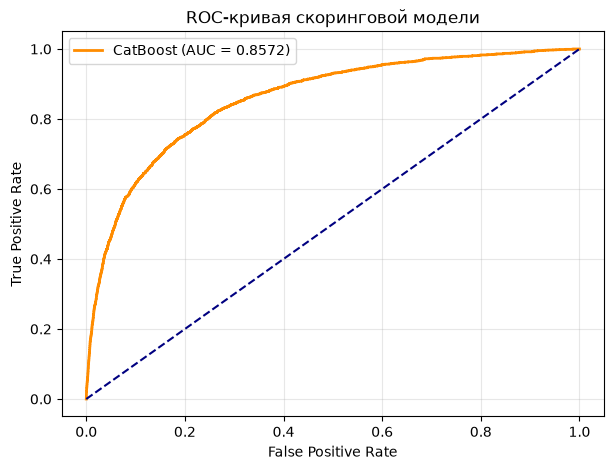

In [9]:
# Получаем вероятности дефолта
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nИтоговый ROC-AUC на тестовой выборке: {auc_score:.4f}")

# Рисуем ROC-кривую
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"CatBoost (AUC = {auc_score:.4f})", color="darkorange", lw=2)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая скоринговой модели")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

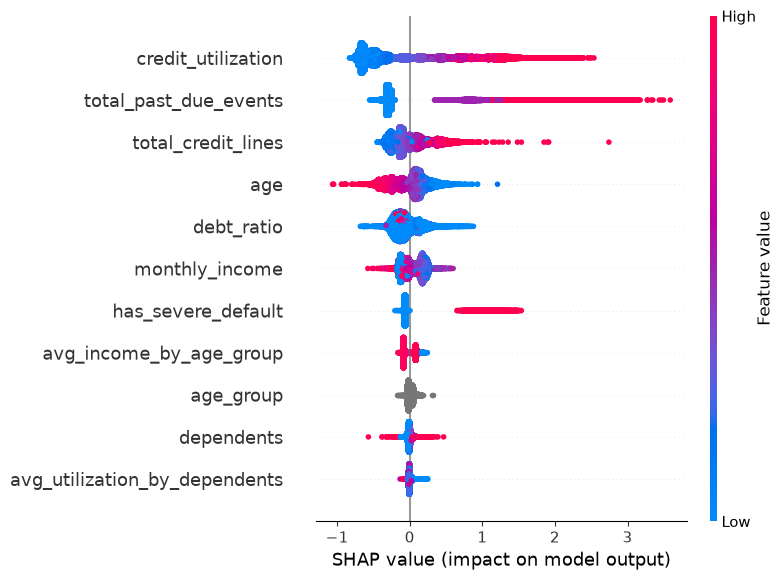

In [10]:
# Расчет SHAP-значений для тестовой выборки
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Построение summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=12)
 